In [64]:
percentile_5 = np.percentile(
    final_portfolio_values,
    5
)

monte_carlo_var = (
    initial_portfolio_value - percentile_5
)

print(f"5th Percentile Final Value: {percentile_5:,.2f}")
print(f"Monte Carlo Downside Amount: {monte_carlo_var:,.2f}")

5th Percentile Final Value: 97,709.02
Monte Carlo Downside Amount: 2,290.98


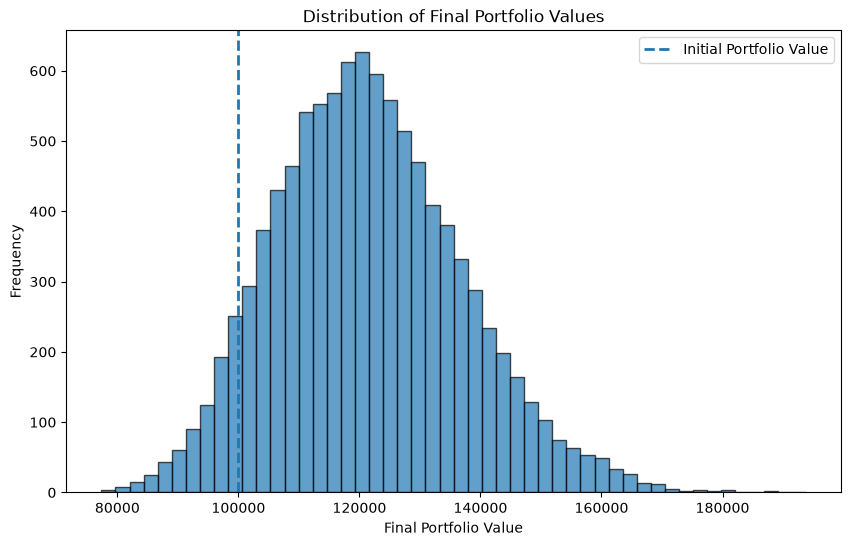

In [63]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_portfolio_values,
    bins=50,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    initial_portfolio_value,
    linestyle="--",
    linewidth=2,
    label="Initial Portfolio Value"
)

plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.title("Distribution of Final Portfolio Values")

plt.legend()
plt.show()

In [62]:
loss_probability = np.mean(
    final_portfolio_values < initial_portfolio_value
)

print(
    f"Probability of ending below initial value: "
    f"{loss_probability:.2%}"
)

Probability of ending below initial value: 7.43%


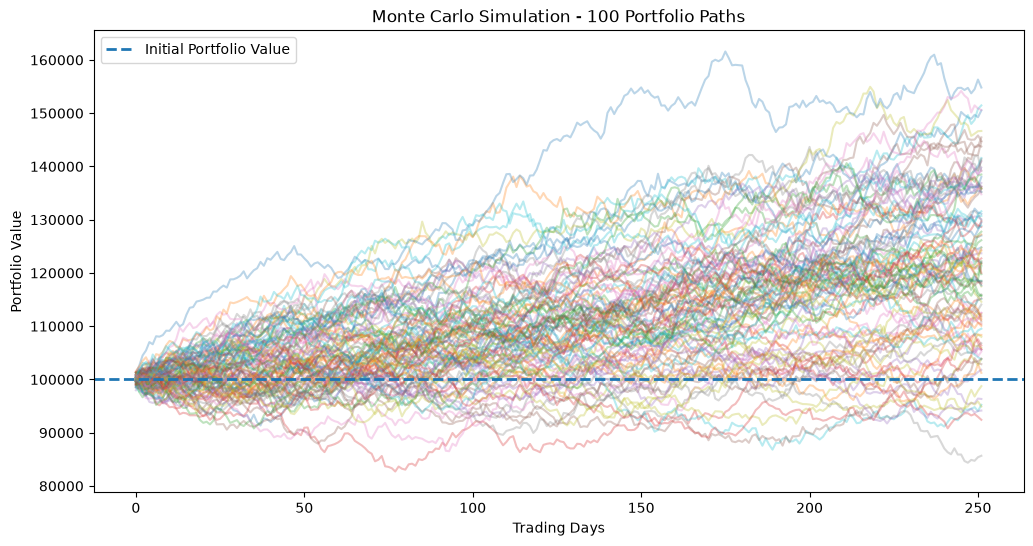

In [61]:
plt.figure(figsize=(12, 6))

plt.plot(
    simulated_portfolio_values[:, :100],
    alpha=0.3
)

plt.axhline(
    initial_portfolio_value,
    linestyle="--",
    linewidth=2,
    label="Initial Portfolio Value"
)

plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.title("Monte Carlo Simulation - 100 Portfolio Paths")

plt.legend()
plt.show()

In [60]:
final_portfolio_values = simulated_portfolio_values[-1, :]

print(f"Average Final Value: {final_portfolio_values.mean():,.2f}")
print(f"Median Final Value: {np.median(final_portfolio_values):,.2f}")
print(f"Worst Final Value: {final_portfolio_values.min():,.2f}")
print(f"Best Final Value: {final_portfolio_values.max():,.2f}")


Average Final Value: 121,453.73
Median Final Value: 120,545.71
Worst Final Value: 77,358.94
Best Final Value: 193,787.30


In [59]:
simulated_portfolio_values = (
    initial_portfolio_value
    * np.cumprod(1 + simulated_returns, axis=0)
)

print("Portfolio values shape:", simulated_portfolio_values.shape)

Portfolio values shape: (252, 10000)


In [58]:
np.random.seed(42)

simulated_returns = np.random.normal(
    daily_mean,
    daily_vol,
    size=(simulation_days, num_simulations)
)

print("Simulation shape:", simulated_returns.shape)

Simulation shape: (252, 10000)


In [57]:
# Monte Carlo Parameters
simulation_days = 252
num_simulations = 10000
initial_portfolio_value = 100000

print("Simulation Days:", simulation_days)
print("Number of Simulations:", num_simulations)
print("Initial Portfolio Value:", initial_portfolio_value)

Simulation Days: 252
Number of Simulations: 10000
Initial Portfolio Value: 100000


In [56]:
np.random.seed(42)

simulated_returns = np.random.normal(
    daily_mean,
    daily_vol,
    size=(simulation_days, num_simulations)
)

print("Simulation shape:", simulated_returns.shape)

NameError: name 'simulation_days' is not defined

In [55]:
daily_mean = portfolio_daily_returns.mean()
daily_vol = portfolio_daily_returns.std()

print(f"Daily Mean Return: {daily_mean:.4%}")
print(f"Daily Volatility: {daily_vol:.4%}")


Daily Mean Return: 0.0776%
Daily Volatility: 0.8067%


In [ ]:
simulation_days = 252
num_simulations = 10000
initial_portfolio_value = 100000

print("Simulation Horizon:", simulation_days, "trading days")
print("Number of Simulations:", num_simulations)
print("Initial Portfolio Value:", initial_portfolio_value)

## Monte Carlo Simulation

In [54]:
portfolio_value = 100000

var_loss = abs(var_95) * portfolio_value
cvar_loss = abs(cvar_95) * portfolio_value

print(f"Portfolio Value: {portfolio_value:,.2f}")
print(f"1-Day VaR (95%): {var_loss:,.2f}")
print(f"1-Day CVaR (95%): {cvar_loss:,.2f}")

Portfolio Value: 100,000.00
1-Day VaR (95%): 1,197.67
1-Day CVaR (95%): 1,750.50


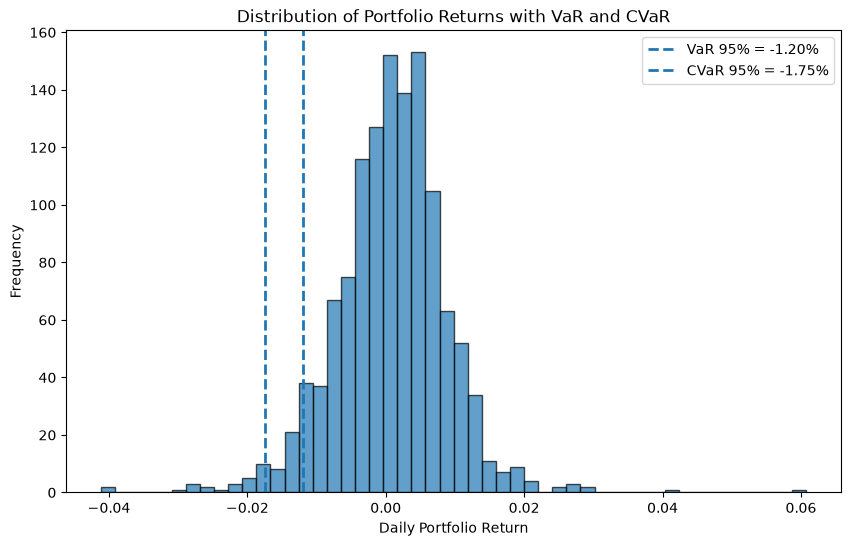

In [53]:
plt.figure(figsize=(10, 6))

# Distribution of daily portfolio returns
plt.hist(
    portfolio_daily_returns,
    bins=50,
    alpha=0.7,
    edgecolor="black"
)

# VaR line
plt.axvline(
    var_95,
    linestyle="--",
    linewidth=2,
    label=f"VaR 95% = {var_95:.2%}"
)

# CVaR line
plt.axvline(
    cvar_95,
    linestyle="--",
    linewidth=2,
    label=f"CVaR 95% = {cvar_95:.2%}"
)

plt.xlabel("Daily Portfolio Return")
plt.ylabel("Frequency")
plt.title("Distribution of Portfolio Returns with VaR and CVaR")

plt.legend()
plt.show()

## VaR & CVaR Visualization

In [52]:
cvar_95 = portfolio_daily_returns[
    portfolio_daily_returns <= var_95
].mean()

print(f"Historical VaR (95%): {var_95:.2%}")
print(f"Historical CVaR (95%): {cvar_95:.2%}")

Historical VaR (95%): -1.20%
Historical CVaR (95%): -1.75%


In [51]:
confidence_level = 0.95

var_95 = np.percentile(
    portfolio_daily_returns,
    (1 - confidence_level) * 100
)

print(f"Historical VaR (95%): {var_95:.2%}")

Historical VaR (95%): -1.20%


In [50]:
print("Number of observations:", len(portfolio_daily_returns))

print("\nPortfolio Daily Returns:")
print(portfolio_daily_returns.head())

print("\nWorst Daily Return:")
print(f"{portfolio_daily_returns.min():.2%}")

print("\nBest Daily Return:")
print(f"{portfolio_daily_returns.max():.2%}")

Number of observations: 1254

Portfolio Daily Returns:
Date
2021-01-05    0.003631
2021-01-06    0.000525
2021-01-07    0.012771
2021-01-08   -0.017674
2021-01-11    0.001473
dtype: float64

Worst Daily Return:
-4.11%

Best Daily Return:
6.07%


In [49]:
# Daily returns of Maximum Sharpe Portfolio
portfolio_daily_returns = returns.dot(max_sharpe_weights)

portfolio_daily_returns.head()

Date
2021-01-05    0.003631
2021-01-06    0.000525
2021-01-07    0.012771
2021-01-08   -0.017674
2021-01-11    0.001473
dtype: float64

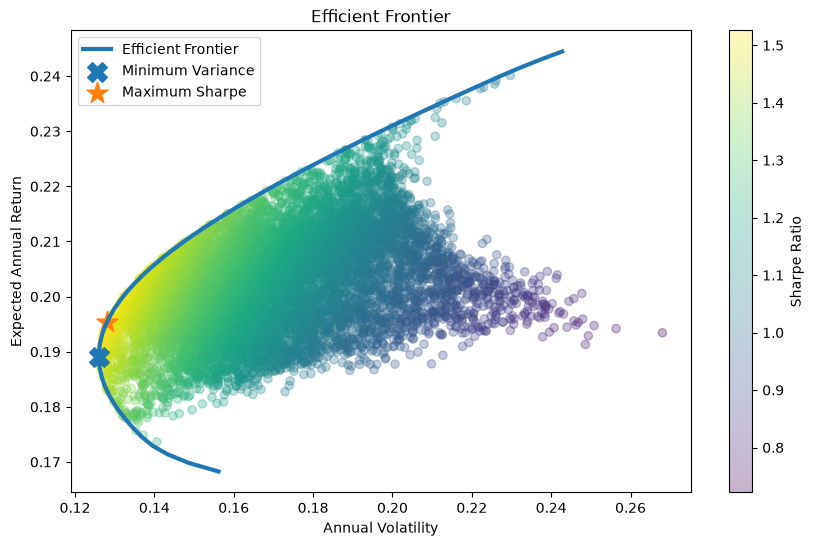

In [48]:
plt.figure(figsize=(10, 6))

# Random portfolios
plt.scatter(
    frontier_df["Volatility"],
    frontier_df["Return"],
    c=frontier_df["Sharpe"],
    cmap="viridis",
    alpha=0.3
)

plt.colorbar(label="Sharpe Ratio")

# True Efficient Frontier
plt.plot(
    frontier_volatilities,
    target_returns,
    linewidth=3,
    label="Efficient Frontier"
)

# Minimum Variance
plt.scatter(
    min_volatility,
    min_return,
    marker="X",
    s=200,
    label="Minimum Variance"
)

# Maximum Sharpe
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier")

plt.legend()
plt.show()

In [47]:
for target_return in target_returns:

    frontier_constraints = (
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        },
        {
            "type": "eq",
            "fun": lambda w, target=target_return:
                np.dot(w, annual_return) - target
        }
    )

    result_frontier = minimize(
        portfolio_volatility,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=frontier_constraints
    )

    if result_frontier.success:
        frontier_volatilities.append(result_frontier.fun)
    else:
        frontier_volatilities.append(np.nan)

In [46]:
target_returns = np.linspace(
    annual_return.min(),
    annual_return.max(),
    50
)

frontier_volatilities = []

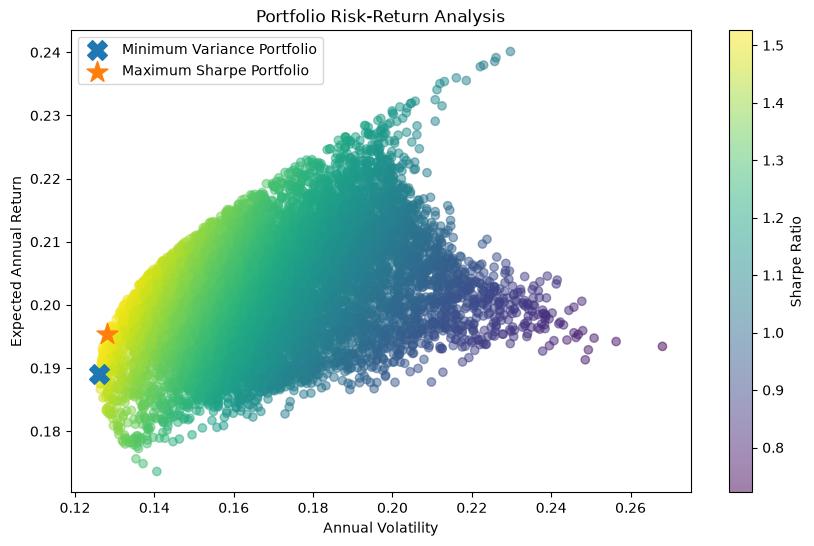

In [45]:
plt.figure(figsize=(10, 6))

# 10,000 random portfolios
plt.scatter(
    frontier_df["Volatility"],
    frontier_df["Return"],
    c=frontier_df["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")


# Minimum Variance Portfolio
plt.scatter(
    min_volatility,
    min_return,
    marker="X",
    s=200,
    label="Minimum Variance Portfolio"
)


# Maximum Sharpe Portfolio
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe Portfolio"
)


plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Portfolio Risk-Return Analysis")

plt.legend()
plt.show()

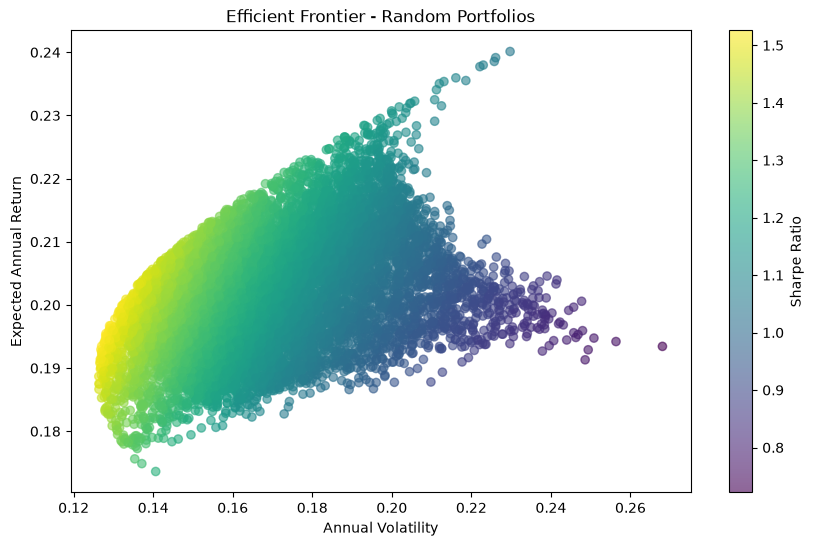

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    frontier_df["Volatility"],
    frontier_df["Return"],
    c=frontier_df["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Efficient Frontier - Random Portfolios")

plt.show()

In [43]:
frontier_df = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe": portfolio_sharpe_ratios
})

frontier_df.head()

,Return,Volatility,Sharpe
0,0.204135,0.191101,1.068206
1,0.192555,0.140271,1.372737
2,0.192060,0.132755,1.446722
3,0.197223,0.166104,1.187348
4,0.187800,0.131895,1.423865


In [42]:
print("Number of portfolios:", len(portfolio_returns))

print("\nFirst portfolio weights:")
print(portfolio_weights[0])

print("\nSum of first portfolio weights:")
print(portfolio_weights[0].sum())

Number of portfolios: 10000

First portfolio weights:
[0.26291909 0.11181977 0.19617936 0.42908179]

Sum of first portfolio weights:
1.0


In [41]:
for i in range(num_portfolios):

    # 1. Generate random weights
    random_weights = np.random.random(len(prices.columns))

    # 2. Make sure weights sum to 1
    random_weights = random_weights / np.sum(random_weights)

    # 3. Calculate portfolio return
    port_return = np.dot(
        random_weights,
        annual_return
    )

    # 4. Calculate portfolio volatility
    port_volatility = portfolio_volatility(
        random_weights,
        covariance_matrix
    )

    # 5. Calculate Sharpe Ratio
    port_sharpe = (
        port_return - risk_free_rate
    ) / port_volatility

    # 6. Save results
    portfolio_returns.append(port_return)
    portfolio_volatilities.append(port_volatility)
    portfolio_sharpe_ratios.append(port_sharpe)
    portfolio_weights.append(random_weights)

In [40]:
num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
portfolio_sharpe_ratios = []
portfolio_weights = []

## Efficient Frontier

In [39]:
# Equal-Weight Portfolio metrics
# Sharpe Ratio of Minimum Variance Portfolio
min_sharpe = (
    min_return - risk_free_rate
) / min_volatility

print(f"Minimum Variance Sharpe Ratio: {min_sharpe:.3f}")
equal_return = np.dot(weights, annual_return)

equal_volatility = portfolio_volatility(
    weights,
    covariance_matrix
)

equal_sharpe = (
    equal_return - risk_free_rate
) / equal_volatility


# Comparison table
comparison = pd.DataFrame({
    "Expected Return (%)": [
        equal_return * 100,
        min_return * 100,
        max_sharpe_return * 100
    ],
    
    "Volatility (%)": [
        equal_volatility * 100,
        min_volatility * 100,
        max_sharpe_volatility * 100
    ],
    
    "Sharpe Ratio": [
        equal_sharpe,
        min_sharpe,
        max_sharpe_ratio
    ]
}, index=[
    "Equal Weight",
    "Minimum Variance",
    "Maximum Sharpe"
])

comparison.round(3)

Minimum Variance Sharpe Ratio: 1.501


,Expected Return (%),Volatility (%),Sharpe Ratio
Equal Weight,20.192,16.132,1.252
Minimum Variance,18.912,12.599,1.501
Maximum Sharpe,19.543,12.807,1.526


In [35]:
max_sharpe_return = np.dot(
    max_sharpe_weights,
    annual_return
)

max_sharpe_volatility = portfolio_volatility(
    max_sharpe_weights,
    covariance_matrix
)

max_sharpe_ratio = (
    max_sharpe_return - risk_free_rate
) / max_sharpe_volatility

print(f"Expected Annual Return: {max_sharpe_return:.2%}")
print(f"Annual Volatility: {max_sharpe_volatility:.2%}")
print(f"Sharpe Ratio: {max_sharpe_ratio:.3f}")

Expected Annual Return: 19.54%
Annual Volatility: 12.81%
Sharpe Ratio: 1.526


In [34]:
max_sharpe_weights = max_sharpe_result.x

print("Optimization successful:", max_sharpe_result.success)
print("\nMaximum Sharpe Weights:")

for asset, weight in zip(prices.columns, max_sharpe_weights):
    print(f"{asset}: {weight:.2%}")

Optimization successful: True

Maximum Sharpe Weights:
AAPL: 2.22%
GLD: 55.50%
JPM: 29.15%
MSFT: 13.12%


In [33]:
max_sharpe_result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(
        annual_return,
        covariance_matrix,
        risk_free_rate
    ),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [32]:
test_sharpe = -negative_sharpe_ratio(
    weights,
    annual_return,
    covariance_matrix,
    risk_free_rate
)

print(f"Equal-Weight Sharpe Ratio: {test_sharpe:.3f}")

Equal-Weight Sharpe Ratio: 1.252


In [30]:
min_volatility = portfolio_volatility(
    optimal_weights,
    covariance_matrix
)

min_return = np.dot(
    optimal_weights,
    annual_return
)

print(f"Expected Annual Return: {min_return:.2%}")
print(f"Minimum Portfolio Volatility: {min_volatility:.2%}")

Expected Annual Return: 18.91%
Minimum Portfolio Volatility: 12.60%


In [31]:
risk_free_rate = 0.0

def negative_sharpe_ratio(
    weights,
    annual_return,
    covariance_matrix,
    risk_free_rate
):
    portfolio_return = np.dot(weights, annual_return)

    portfolio_vol = portfolio_volatility(
        weights,
        covariance_matrix
    )

    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_vol

    return -sharpe_ratio

In [29]:
optimal_weights = result.x

print("Optimization successful:", result.success)
print("\nOptimal Weights:")

for asset, weight in zip(prices.columns, optimal_weights):
    print(f"{asset}: {weight:.2%}")

Optimization successful: True

Optimal Weights:
AAPL: 4.86%
GLD: 62.72%
JPM: 20.56%
MSFT: 11.86%


In [27]:
result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(covariance_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [26]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds = tuple(
    (0, 1) for asset in range(len(initial_weights))
)

In [25]:
initial_weights = np.array([0.25, 0.25, 0.25, 0.25])

print(initial_weights)
print("Sum:", initial_weights.sum())

[0.25 0.25 0.25 0.25]
Sum: 1.0


In [ ]:
constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}
bounds = tuple(
    (0, 1) for asset in range(len(weights))
)

print(bounds)

In [20]:
test_volatility = portfolio_volatility(
    weights,
    covariance_matrix
)

print(f"Test Portfolio Volatility: {test_volatility:.2%}")

Test Portfolio Volatility: 16.13%


In [19]:
def portfolio_volatility(weights, covariance_matrix):
    portfolio_variance = np.dot(
        weights.T,
        np.dot(covariance_matrix, weights)
    )
    
    return np.sqrt(portfolio_variance)

In [18]:
from scipy.optimize import minimize

In [17]:
print("=== Equal-Weighted Portfolio ===")
print(f"Expected Annual Return: {portfolio_return:.2%}")
print(f"Annual Volatility: {portfolio_volatility:.2%}")

=== Equal-Weighted Portfolio ===
Expected Annual Return: 20.19%
Annual Volatility: 16.13%


In [16]:
portfolio_variance = np.dot(
    weights.T,
    np.dot(covariance_matrix, weights)
)

portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Annual Portfolio Volatility: {portfolio_volatility:.2%}")

Annual Portfolio Volatility: 16.13%


In [15]:
portfolio_return = np.dot(weights, annual_return)

print(f"Expected Annual Portfolio Return: {portfolio_return:.2%}")

Expected Annual Portfolio Return: 20.19%


In [14]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

print("Portfolio weights:", weights)
print("Sum of weights:", weights.sum())

Portfolio weights: [0.25 0.25 0.25 0.25]
Sum of weights: 1.0


In [13]:
covariance_matrix = returns.cov() * 252

covariance_matrix

,AAPL,GLD,JPM,MSFT
AAPL,0.077633,0.003093,0.023363,0.045421
GLD,0.003093,0.024384,0.000490,0.002852
JPM,0.023363,0.000490,0.058926,0.019430
MSFT,0.045421,0.002852,0.019430,0.066123


In [12]:
correlation_matrix = returns.corr()

correlation_matrix

,AAPL,GLD,JPM,MSFT
AAPL,1.000000,0.071100,0.345423,0.633958
GLD,0.071100,1.000000,0.012929,0.071022
JPM,0.345423,0.012929,1.000000,0.311269
MSFT,0.633958,0.071022,0.311269,1.000000


In [11]:
trading_days = 252

annual_return = mean_daily_returns * trading_days
annual_volatility = daily_volatility * np.sqrt(trading_days)

annual_summary = pd.DataFrame({
    "Annualized Return (%)": annual_return * 100,
    "Annualized Volatility (%)": annual_volatility * 100
})

annual_summary

,Annualized Return (%),Annualized Volatility (%)
AAPL,19.322602,27.862643
GLD,16.826781,15.615484
JPM,24.446994,24.274649
MSFT,20.172543,25.714314


In [10]:
summary = pd.DataFrame({
    "Mean Daily Return (%)": mean_daily_returns * 100,
    "Daily Volatility (%)": daily_volatility * 100
})

summary

,Mean Daily Return (%),Daily Volatility (%)
AAPL,0.076677,1.755182
GLD,0.066773,0.983683
JPM,0.097012,1.529159
MSFT,0.080050,1.619850


In [9]:
daily_volatility = returns.std()

print("Daily Volatility:")
print(daily_volatility)

Daily Volatility:
AAPL    0.017552
GLD     0.009837
JPM     0.015292
MSFT    0.016198
dtype: float64


In [8]:
mean_daily_returns = returns.mean()

print("Mean Daily Returns:")
print(mean_daily_returns)

Mean Daily Returns:
AAPL    0.000767
GLD     0.000668
JPM     0.000970
MSFT    0.000800
dtype: float64


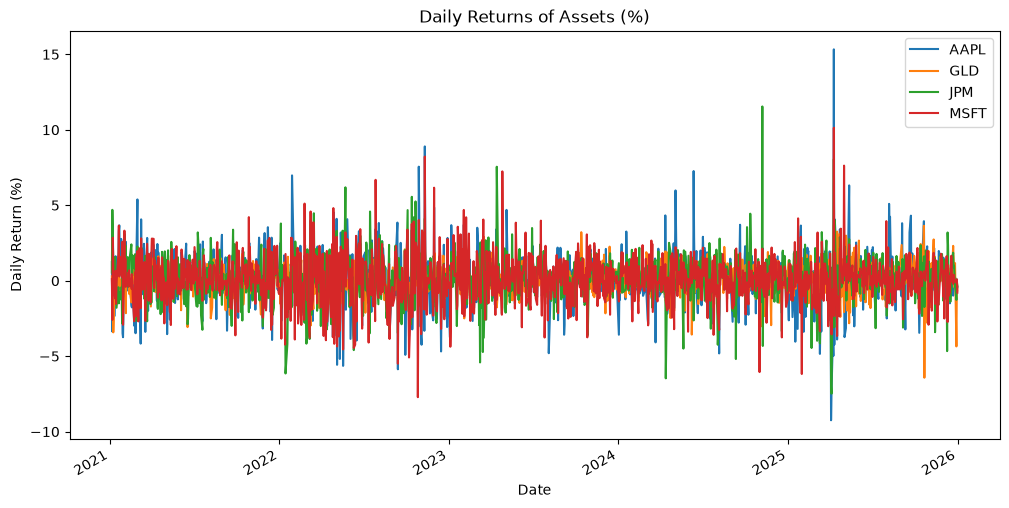

In [7]:
returns_percent.plot(
    figsize=(12, 6),
    title="Daily Returns of Assets (%)"
)

plt.ylabel("Daily Return (%)")
plt.xlabel("Date")
plt.show()

In [6]:
returns_percent = returns * 100

returns_percent.head()

,AAPL,GLD,JPM,MSFT
Date,,,,
2021-01-05,1.236352,0.296163,0.544134,0.096464
2021-01-06,-3.366145,-1.624105,4.695573,-2.592933
2021-01-07,3.412287,-0.233462,3.283947,2.845714
2021-01-08,0.863153,-3.420994,0.110384,0.609252
2021-01-11,-2.324864,-0.196144,1.492439,-0.969825


In [5]:
returns = returns.dropna()

returns.head()
print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)

Prices shape: (1255, 4)
Returns shape: (1254, 4)


In [3]:
returns = prices.pct_change()

returns.head()

,AAPL,GLD,JPM,MSFT
Date,,,,
2021-01-04,NaN,NaN,NaN,NaN
2021-01-05,0.012364,0.002962,0.005441,0.000965
2021-01-06,-0.033661,-0.016241,0.046956,-0.025929
2021-01-07,0.034123,-0.002335,0.032839,0.028457
2021-01-08,0.008632,-0.034210,0.001104,0.006093


In [2]:
project_root = Path.cwd().parent

prices = pd.read_csv(
    project_root / "data" / "processed" / "close_prices.csv",
    index_col="Date",
    parse_dates=True
)

prices.head()

,AAPL,GLD,JPM,MSFT
Date,,,,
2021-01-04,125.632523,182.330002,109.000526,207.565384
2021-01-05,127.185783,182.869995,109.593636,207.765610
2021-01-06,122.904526,179.899994,114.739685,202.378387
2021-01-07,127.098381,179.479996,118.507675,208.137497
2021-01-08,128.195435,173.339996,118.638489,209.405579


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path